# 😊 Sentiment Analysis

## Text and Speech Analysis – Mini Project

This project analyzes a given text and classifies its sentiment as Positive, Negative, or Neutral using Natural Language Processing.

In [2]:
!pip install -q nltk

In [3]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [4]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [5]:
sia = SentimentIntensityAnalyzer()

In [6]:
text = "I love this project. It is amazing!"

scores = sia.polarity_scores(text)

print(scores)

{'neg': 0.0, 'neu': 0.325, 'pos': 0.675, 'compound': 0.8516}


In [7]:
def analyze_sentiment(text):

    score = sia.polarity_scores(text)

    compound = score["compound"]

    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return sentiment, compound

In [8]:
text = "I really enjoyed this movie. It was fantastic!"

sentiment, score = analyze_sentiment(text)

print("Text:", text)
print("Sentiment:", sentiment)
print("Compound Score:", score)

Text: I really enjoyed this movie. It was fantastic!
Sentiment: Positive
Compound Score: 0.8169


In [9]:
text = "I hated this movie. It was boring and terrible."

sentiment, score = analyze_sentiment(text)

print("Text:", text)
print("Sentiment:", sentiment)
print("Compound Score:", score)

Text: I hated this movie. It was boring and terrible.
Sentiment: Negative
Compound Score: -0.8625


In [10]:
text = "The movie was released yesterday."

sentiment, score = analyze_sentiment(text)

print("Text:", text)
print("Sentiment:", sentiment)
print("Compound Score:", score)

Text: The movie was released yesterday.
Sentiment: Neutral
Compound Score: 0.0


In [11]:
texts = [
    "I love this product!",
    "This is the worst service ever.",
    "The weather is okay today.",
    "The food was absolutely delicious.",
    "I am very disappointed with the result.",
    "The meeting starts at 10 AM."
]

In [12]:
for text in texts:

    sentiment, score = analyze_sentiment(text)

    print("Text:", text)
    print("Sentiment:", sentiment)
    print("Score:", round(score, 3))
    print("-" * 50)

Text: I love this product!
Sentiment: Positive
Score: 0.67
--------------------------------------------------
Text: This is the worst service ever.
Sentiment: Negative
Score: -0.625
--------------------------------------------------
Text: The weather is okay today.
Sentiment: Positive
Score: 0.226
--------------------------------------------------
Text: The food was absolutely delicious.
Sentiment: Positive
Score: 0.612
--------------------------------------------------
Text: I am very disappointed with the result.
Sentiment: Negative
Score: -0.526
--------------------------------------------------
Text: The meeting starts at 10 AM.
Sentiment: Neutral
Score: 0.0
--------------------------------------------------


In [13]:
import pandas as pd

results = []

for text in texts:

    sentiment, score = analyze_sentiment(text)

    results.append({
        "Text": text,
        "Sentiment": sentiment,
        "Compound Score": score
    })

df = pd.DataFrame(results)

display(df)

,Text,Sentiment,Compound Score
0,I love this product!,Positive,0.6696
1,This is the worst service ever.,Negative,-0.6249
2,The weather is okay today.,Positive,0.2263
3,The food was absolutely delicious.,Positive,0.6115
4,I am very disappointed with the result.,Negative,-0.5256
5,The meeting starts at 10 AM.,Neutral,0.0000


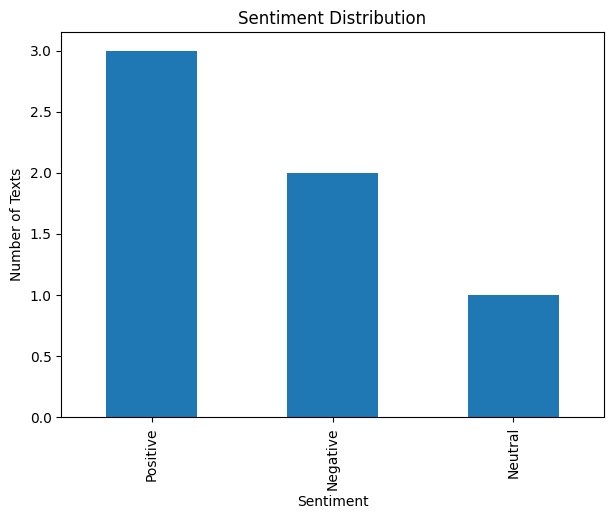

In [14]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")

plt.show()

In [15]:
user_text = input("Enter a sentence: ")

sentiment, score = analyze_sentiment(user_text)

print("\nText:", user_text)
print("Sentiment:", sentiment)
print("Compound Score:", round(score, 3))

Enter a sentence: I love you

Text: I love you
Sentiment: Positive
Compound Score: 0.637


In [16]:
!pip install -q gradio

In [17]:
import gradio as gr

In [18]:
def sentiment_app(text):

    sentiment, score = analyze_sentiment(text)

    return sentiment, round(score, 3)

In [19]:
with gr.Blocks() as app:

    gr.Markdown("# 😊 Sentiment Analysis")

    gr.Markdown(
        "Enter text below to determine whether its sentiment is Positive, Negative, or Neutral."
    )

    text_input = gr.Textbox(
        label="Enter Text",
        placeholder="Example: I really enjoyed this product!"
    )

    analyze_button = gr.Button("Analyze Sentiment")

    sentiment_output = gr.Textbox(
        label="Sentiment"
    )

    score_output = gr.Number(
        label="Compound Score"
    )

    analyze_button.click(
        sentiment_app,
        inputs=text_input,
        outputs=[sentiment_output, score_output]
    )

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08d4e3e463dc7a407f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
